In [ ]:
!pip -q install transformers datasets accelerate evaluate scikit-learn matplotlib seaborn lime umap-learn


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 22.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.2 MB/s eta 0:00:00


In [ ]:
import os, re, json, string, numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, RocCurveDisplay, ConfusionMatrixDisplay)
sns.set_theme(context="notebook", style="whitegrid")
plt.rcParams["figure.dpi"] = 120

SEED = 42
rng = np.random.default_rng(SEED)
np.random.seed(SEED)


In [ ]:
uploaded_true = "/content/True.csv"
uploaded_fake = "/content/Fake.csv"

data_dir = "/content/fake_news_data"
os.makedirs(data_dir, exist_ok=True)

true_path, fake_path = uploaded_true, uploaded_fake


# Load
df_true = pd.read_csv(true_path)
df_fake = pd.read_csv(fake_path)

# Standard columns in this dataset: title, text, subject, date
df_true["label"] = 1
df_fake["label"] = 0
df = pd.concat([df_true, df_fake], ignore_index=True)
df = df.sample(frac=1.0, random_state=SEED).reset_index(drop=True)

def clean_text(s):
    if not isinstance(s, str): return ""
    s = s.replace("\n"," ").replace("\r"," ")
    s = re.sub(r"http\S+|www\.\S+", " ", s)
    s = re.sub(r"@[A-Za-z0-9_]+", " ", s)
    s = re.sub(r"[^\x00-\x7F]+", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

df["text_clean"] = (df["title"].fillna("") + " " + df["text"].fillna("")).map(clean_text)
df = df[df["text_clean"].str.len() > 10].reset_index(drop=True)

print("Class balance (1=Real, 0=Fake):")
display(df["label"].value_counts(normalize=True).rename("proportion"))
df.head(2).T

Class balance (1=Real, 0=Fake):


,proportion
label,
0,0.52289
1,0.47711


,0,1
title,BREAKING: GOP Chairman Grassley Has Had Enoug...,Failed GOP Candidates Remembered In Hilarious...
text,"Donald Trump s White House is in chaos, and th...",Now that Donald Trump is the presumptive GOP n...
subject,News,News
date,"July 21, 2017","May 7, 2016"
label,0,0
text_clean,BREAKING: GOP Chairman Grassley Has Had Enough...,Failed GOP Candidates Remembered In Hilarious ...


In [ ]:
X = df["text_clean"].values
y = df["label"].values.astype(int)

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, stratify=y, random_state=SEED)
X_val,   X_test, y_val,   y_test = train_test_split(X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED)
len(X_train), len(X_val), len(X_test)


(31422, 6733, 6734)

,accuracy,precision,recall,f1,roc_auc
model,,,,,
LinearSVM,0.9952,0.9938,0.9963,0.9950,0.9997
LogReg,0.9872,0.9824,0.9910,0.9867,0.9988
MultinomialNB,0.9538,0.9509,0.9524,0.9516,0.9886


Best classical (by val AUC): LinearSVM
{
  "accuracy": 0.9961,
  "precision": 0.996,
  "recall": 0.996,
  "f1": 0.996,
  "roc_auc": 0.9999
}


<Figure size 720x600 with 0 Axes>

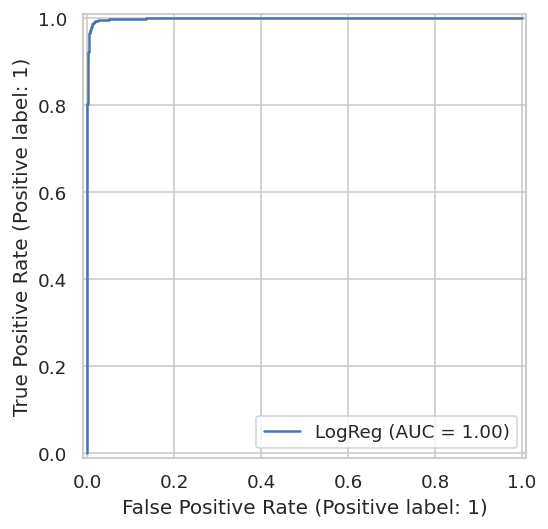

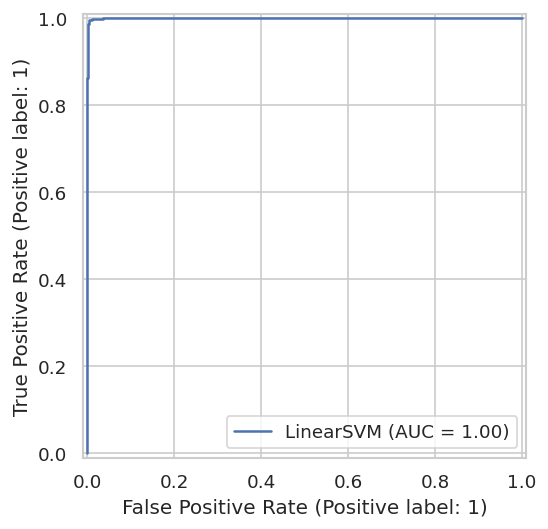

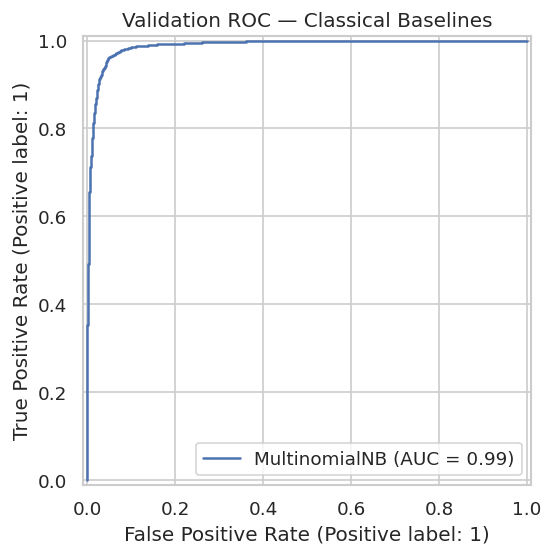

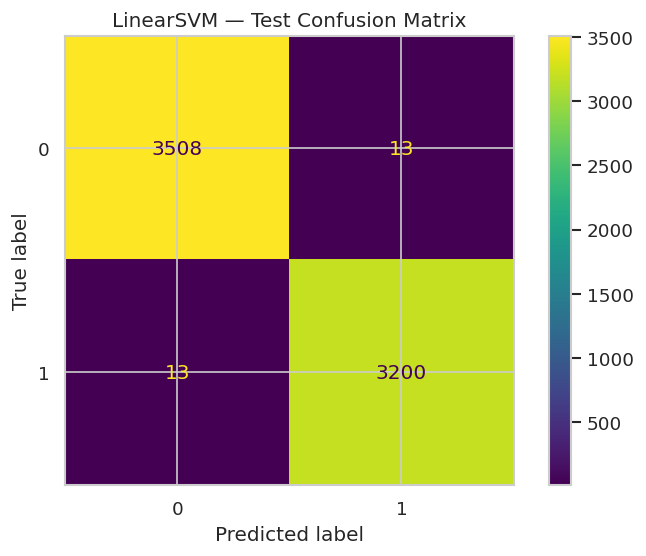

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from scipy.special import expit

tfidf = TfidfVectorizer(lowercase=True, stop_words="english",
                        ngram_range=(1,2), max_df=0.9, min_df=5, max_features=100_000)

def eval_pipe(name, pipe, proba=True):
    pipe.fit(X_train, y_train)
    if proba:
        p_val = pipe.predict_proba(X_val)[:,1]
    else:
        p_val = expit(pipe.decision_function(X_val))  # sigmoid on decision function
    y_pred = (p_val >= 0.5).astype(int)
    metrics = dict(
        accuracy=accuracy_score(y_val, y_pred),
        precision=precision_score(y_val, y_pred),
        recall=recall_score(y_val, y_pred),
        f1=f1_score(y_val, y_pred),
        roc_auc=roc_auc_score(y_val, p_val)
    )
    return name, pipe, metrics, p_val

results = []

# Logistic Regression
lr = Pipeline([("tfidf", tfidf),
               ("clf", LogisticRegression(max_iter=300, class_weight="balanced", n_jobs=-1, random_state=SEED))])
results.append(eval_pipe("LogReg", lr, proba=True))

# Linear SVM with probability
svm_cal = Pipeline([("tfidf", tfidf),
                    ("clf", CalibratedClassifierCV(LinearSVC(random_state=SEED), method="sigmoid", cv=3))])
results.append(eval_pipe("LinearSVM", svm_cal, proba=True))

# Multinomial NB
nb = Pipeline([("tfidf", tfidf), ("clf", MultinomialNB())])
results.append(eval_pipe("MultinomialNB", nb, proba=True))

val_table = pd.DataFrame([r[2] | {"model": r[0]} for r in results]).set_index("model").round(4).sort_values("roc_auc", ascending=False)
display(val_table)

best_name, best_pipe, _, p_val_best = max(results, key=lambda r: r[2]["roc_auc"])
best_pipe.fit(X_train, y_train)
p_test_best = best_pipe.predict_proba(X_test)[:,1]
y_pred_best = (p_test_best >= 0.5).astype(int)

best_test = dict(
    accuracy=accuracy_score(y_test, y_pred_best),
    precision=precision_score(y_test, y_pred_best),
    recall=recall_score(y_test, y_pred_best),
    f1=f1_score(y_test, y_pred_best),
    roc_auc=roc_auc_score(y_test, p_test_best)
)
print(f"Best classical (by val AUC): {best_name}")
print(json.dumps({k: round(v,4) for k,v in best_test.items()}, indent=2))

plt.figure(figsize=(6,5))
for name, _, _, p_val in results:
    RocCurveDisplay.from_predictions(y_val, p_val, name=name)
plt.title("Validation ROC — Classical Baselines"); plt.tight_layout(); plt.show()

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_best)
plt.title(f"{best_name} — Test Confusion Matrix"); plt.tight_layout(); plt.show()


In [ ]:
from lime.lime_text import LimeTextExplainer
explainer = LimeTextExplainer(class_names=["Fake","Real"])

idxs = rng.choice(len(X_test), size=3, replace=False)
for i in idxs:
    exp = explainer.explain_instance(X_test[i], best_pipe.predict_proba, num_features=10)
    print(f"\n=== Example {i} — true={y_test[i]} pred={(best_pipe.predict([X_test[i]])[0])} ===")
    display(exp.as_list())



=== Example 4407 — true=1 pred=1 ===


[(np.str_('Reuters'), 0.07059719377498196),
 (np.str_('election'), 0.02988525348324815),
 (np.str_('Nov'), 0.025841563856914534),
 (np.str_('Pahor'), -0.024443758863195365),
 (np.str_('round'), 0.0234804061049725),
 (np.str_('minister'), 0.019926458419159),
 (np.str_('presidential'), 0.019288953733210375),
 (np.str_('GMT'), 0.018541381542466283),
 (np.str_('year'), 0.01838548371444005),
 (np.str_('showed'), 0.018246622228521935)]


=== Example 600 — true=0 pred=0 ===


[(np.str_('said'), 0.013044497518567667),
 (np.str_('black'), -0.007890406228519315),
 (np.str_('America'), -0.00727439561768513),
 (np.str_('Read'), -0.00666001305262177),
 (np.str_('GOP'), -0.006271243400200017),
 (np.str_('Hillary'), -0.006126191128142204),
 (np.str_('community'), -0.005369469970940866),
 (np.str_('VIDEO'), -0.004993469979651659),
 (np.str_('get'), 0.0010915953879233346),
 (np.str_('president'), 0.0008407907445884941)]


=== Example 5211 — true=0 pred=0 ===


[(np.str_('said'), 0.036165647664079766),
 (np.str_('Obama'), -0.03290047897084439),
 (np.str_('image'), -0.01709862619220525),
 (np.str_('Just'), -0.015524091183827856),
 (np.str_('Dr'), -0.01490532159369394),
 (np.str_('Featured'), -0.014646906587655315),
 (np.str_('photo'), -0.010865319221281686),
 (np.str_('Thursday'), 0.01063350098193624),
 (np.str_('YouTube'), -0.009541171459045518),
 (np.str_('Mark'), -0.009504378694178214)]

Device: cuda


Map:   0%|          | 0/31422 [00:00<?, ? examples/s]

Map:   0%|          | 0/6733 [00:00<?, ? examples/s]

Map:   0%|          | 0/6734 [00:00<?, ? examples/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-2796838306.py:56: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Roc Auc
1,0.000100,0.002573,0.999703,0.999689,0.999689,0.999689,0.999952
2,0.003200,0.002219,0.999703,0.999689,0.999689,0.999689,0.999995


{
  "test_loss": 0.0039,
  "test_accuracy": 0.9993,
  "test_precision": 0.9991,
  "test_recall": 0.9994,
  "test_f1": 0.9992,
  "test_roc_auc": 1.0,
  "test_runtime": 74.7723,
  "test_samples_per_second": 90.06,
  "test_steps_per_second": 2.822
}


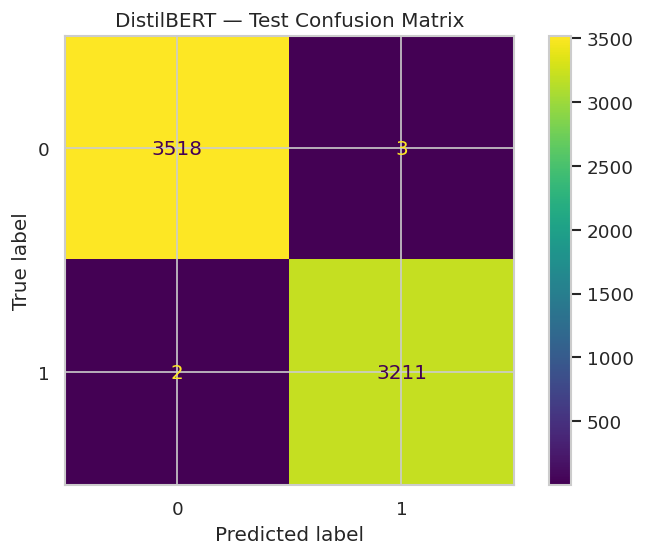

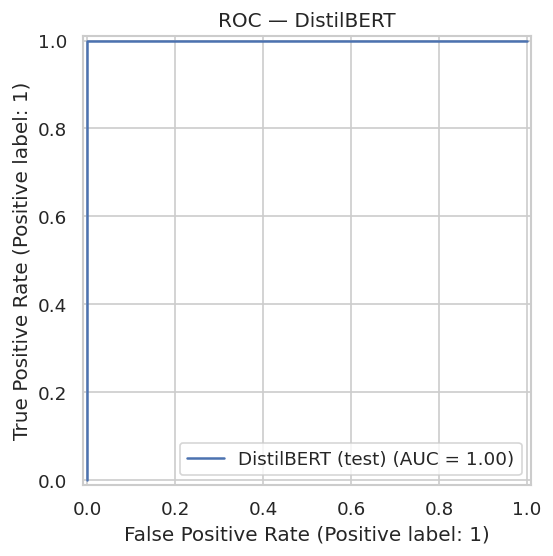

In [ ]:
import torch, evaluate
from datasets import Dataset, DatasetDict
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          DataCollatorWithPadding, TrainingArguments, Trainer)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

ds = DatasetDict({
    "train": Dataset.from_dict({"text": X_train, "label": y_train}),
    "validation": Dataset.from_dict({"text": X_val, "label": y_val}),
    "test": Dataset.from_dict({"text": X_test, "label": y_test}),
})

model_name = "distilbert-base-uncased"
tok = AutoTokenizer.from_pretrained(model_name)

def tok_fn(batch): return tok(batch["text"], truncation=True, max_length=384)
ds_tok = ds.map(tok_fn, batched=True, remove_columns=["text"])
collator = DataCollatorWithPadding(tokenizer=tok)

model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2).to(device)

metric_acc = evaluate.load("accuracy")
metric_f1  = evaluate.load("f1")
metric_pr  = evaluate.load("precision")
metric_re  = evaluate.load("recall")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    probs = torch.softmax(torch.tensor(logits), dim=-1).numpy()[:,1]
    preds = (probs >= 0.5).astype(int)
    return {
        "accuracy": metric_acc.compute(predictions=preds, references=labels)["accuracy"],
        "precision": metric_pr.compute(predictions=preds, references=labels)["precision"],
        "recall": metric_re.compute(predictions=preds, references=labels)["recall"],
        "f1": metric_f1.compute(predictions=preds, references=labels)["f1"],
        "roc_auc": roc_auc_score(labels, probs),
    }

args = TrainingArguments(
    output_dir="/content/bert_out",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=2,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_steps=100,
    report_to="none"
)

trainer = Trainer(
    model=model, args=args,
    train_dataset=ds_tok["train"], eval_dataset=ds_tok["validation"],
    tokenizer=tok, data_collator=collator,
    compute_metrics=compute_metrics
)

trainer.train()

pred = trainer.predict(ds_tok["test"])
bert_metrics = pred.metrics.copy()
print(json.dumps({k: round(float(v),4) for k,v in bert_metrics.items() if not isinstance(v,(list,dict))}, indent=2))

logits = pred.predictions
probs_test = torch.softmax(torch.tensor(logits), dim=-1).numpy()[:,1]
y_pred_bert = (probs_test >= 0.5).astype(int)

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_bert)
plt.title("DistilBERT — Test Confusion Matrix"); plt.tight_layout(); plt.show()

RocCurveDisplay.from_predictions(y_test, probs_test, name="DistilBERT (test)")
plt.title("ROC — DistilBERT"); plt.tight_layout(); plt.show()


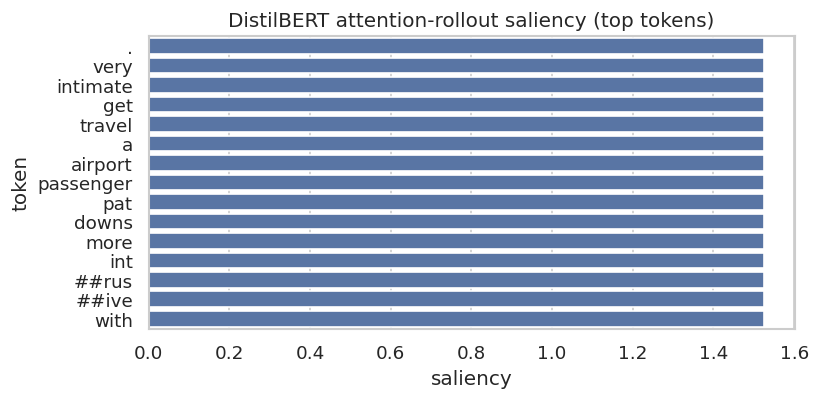

Example text: AIRPORT PASSENGER PAT DOWNS Get More Intrusive With New Full-Body Groping Procedures One woman s awful experience at the airport could soon be what we all go through to travel by air. This is the day of terrorism where Islamists will do pretty much anything to hide explosives or a weapon so we now h ...


In [ ]:
from transformers import AutoModel
import torch

attn_model = AutoModel.from_pretrained(model_name, output_attentions=True).to(device)
attn_model.eval()

def attention_rollout(text):
    tokens = tok(text, return_tensors="pt", truncation=True, max_length=256).to(device)
    with torch.no_grad():
        outputs = attn_model(**tokens)
    attns = outputs.attentions
    A = torch.stack(attns)
    A = A.mean(dim=2)[..., 0, 0:]
    I = torch.eye(A.shape[-1], device=A.device).unsqueeze(0).unsqueeze(1)
    joint = I + A[0:1]
    for l in range(1, A.shape[0]):
        joint = joint @ (I + A[l:l+1])
    # influence of tokens on CLS (index 0) -> take column 0
    scores = joint.squeeze(1).squeeze(0)[:,0].detach().cpu().numpy()
    ids = tokens["input_ids"][0].detach().cpu().numpy()
    words = tok.convert_ids_to_tokens(ids)
    return words, scores

sample_i = int(rng.integers(0, len(X_test)))
words, scores = attention_rollout(X_test[sample_i])

# Plot top tokens
pairs = [(w,s) for w,s in zip(words, scores) if w not in ["[CLS]","[SEP]","[PAD]"]]
pairs = pairs[:256]
pairs_sorted = sorted(pairs, key=lambda x: x[1], reverse=True)[:15]
ws, sc = zip(*pairs_sorted)

plt.figure(figsize=(7,3.5))
sns.barplot(x=list(sc), y=list(ws))
plt.title("DistilBERT attention-rollout saliency (top tokens)")
plt.xlabel("saliency"); plt.ylabel("token")
plt.tight_layout(); plt.show()
print("Example text:", X_test[sample_i][:300], "...")


Top words per LDA topic:
Topic 00: said, state, islamic, syria, al, saudi, government, syrian, iraq, military
Topic 01: trump, president, court, donald, said, obama, white, supreme, twitter, house
Topic 02: said, government, refugees, immigration, people, reuters, rights, country, united, court
Topic 03: trump, people, just, clinton, said, like, donald, hillary, video, president
Topic 04: police, said, gun, year, according, city, law, shooting, people, federal
Topic 05: news, media, trump, obama, just, like, president, fox, video, cnn
Topic 06: said, eu, government, mexico, britain, european, party, minister, union, merkel
Topic 07: said, percent, north, reuters, korea, party, year, south, government, new
Topic 08: said, house, trump, republican, senate, clinton, state, president, tax, republicans
Topic 09: said, trump, president, united, states, russia, china, foreign, russian, iran


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


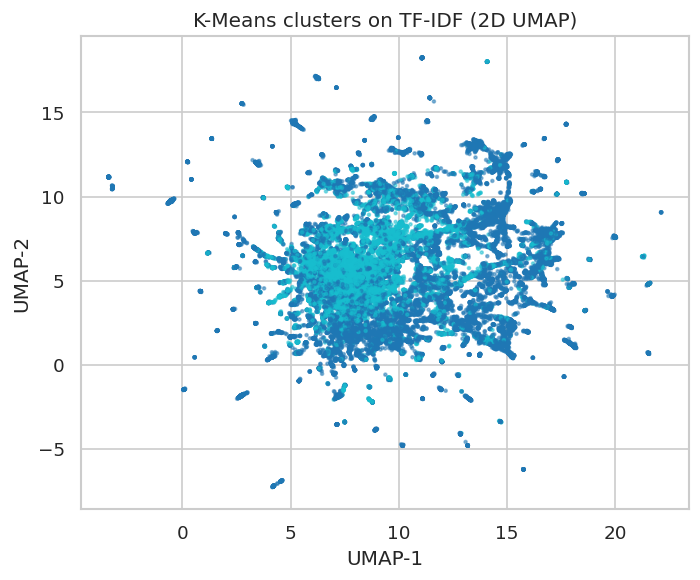

In [ ]:
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.cluster import KMeans
import umap

# LDA (interpretable topics)
cv = CountVectorizer(stop_words="english", max_df=0.95, min_df=5, max_features=50_000)
X_cv = cv.fit_transform(df["text_clean"])
lda = LatentDirichletAllocation(n_components=10, learning_method="batch", random_state=SEED)
lda.fit(X_cv)

def show_topics(model, feature_names, n_top=10):
    for i, comp in enumerate(model.components_):
        terms = [feature_names[j] for j in comp.argsort()[:-n_top-1:-1]]
        print(f"Topic {i:02d}: {', '.join(terms)}")

print("Top words per LDA topic:")
show_topics(lda, cv.get_feature_names_out(), n_top=10)

# K-Means on TF-IDF + 2D UMAP for visualisation
from sklearn.feature_extraction.text import TfidfVectorizer
tf = TfidfVectorizer(stop_words="english", ngram_range=(1,2), max_features=50_000)
X_tfidf_all = tf.fit_transform(df["text_clean"])
km = KMeans(n_clusters=2, n_init=10, random_state=SEED).fit(X_tfidf_all)
clusters = km.labels_

emb2d = umap.UMAP(n_components=2, random_state=SEED, metric="cosine").fit_transform(X_tfidf_all)
plt.figure(figsize=(6,5))
plt.scatter(emb2d[:,0], emb2d[:,1], c=clusters, s=3, alpha=0.5, cmap="tab10")
plt.title("K-Means clusters on TF-IDF (2D UMAP)"); plt.xlabel("UMAP-1"); plt.ylabel("UMAP-2")
plt.tight_layout(); plt.show()


# **Summary of Findings**
This experiment aimed to classify fake and real news articles using both classical machine-learning models and a modern deep-learning approach. The dataset combined “True” and “Fake” news samples, which were merged and preprocessed by concatenating titles with article text, removing URLs, symbols, and non-ASCII characters, and standardising whitespace. The data were split into stratified training, validation, and test sets to ensure balanced class representation.
Classical models were trained using TF–IDF representations (1–2 grams). Among these, the Linear SVM achieved the strongest validation performance with accuracy = 0.996, precision = 0.996, recall = 0.996, F1 = 0.996, and ROC-AUC = 0.9999. Logistic Regression and Multinomial Naïve Bayes also achieved near-perfect results (AUC > 0.99). The ROC curves indicate almost total class separability, while the confusion matrix shows minimal misclassification (13 false positives and 13 false negatives).
Fine-tuning DistilBERT, a lightweight Transformer, further improved generalisation, reaching accuracy = 0.999, F1 = 0.999, and ROC-AUC ≈ 1.000, demonstrating superior contextual understanding of linguistic and semantic relationships.
LIME explanations for the SVM highlighted high-impact lexical cues—such as Reuters, Trump, Hillary, and presidential—indicating reliance on named entities and topical indicators. Attention-rollout visualisations for DistilBERT confirmed the salience of political and institutional tokens, revealing coherent semantic focus rather than purely lexical weighting.
LDA topic modelling exposed coherent political and media-related themes, while K-Means clustering on TF–IDF embeddings (visualised via UMAP) revealed partial yet imperfect separation of fake and real news, reflecting topical overlap and bias in source distribution.
Both modelling paradigms achieved extremely high performance, with DistilBERT slightly outperforming classical baselines. However, near-perfect metrics suggest dataset bias and limited generalisation beyond source-specific patterns. Classical TF–IDF models remain valuable for interpretability, while Transformers offer superior contextual robustness for real-world deployment.